In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pygam import LinearGAM, s
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json
import os

df = pd.read_csv('../data/tarkwa_nasa_monthly.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# GAM needs a numeric time index as its single predictor for the univariate case
df['t'] = np.arange(len(df))
df['month_num'] = df['date'].dt.month

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(df[['date', 'rainfall_mm', 't', 'month_num']].head())

Dataset shape: (438, 13)
Date range: 1990-01-01 00:00:00 to 2026-06-01 00:00:00
        date  rainfall_mm  t  month_num
0 1990-01-01        36.92  0          1
1 1990-02-01        98.45  1          2
2 1990-03-01        70.49  2          3
3 1990-04-01       251.53  3          4
4 1990-05-01       187.32  4          5


In [2]:
split_date = '2019-01-01'

train_df = df[df['date'] < split_date].reset_index(drop=True)
test_df  = df[df['date'] >= split_date].reset_index(drop=True)

# Univariate GAM predictors: time trend (t) + month-of-year seasonality (month_num)
X_train = train_df[['t', 'month_num']].values
X_test  = test_df[['t', 'month_num']].values
y_train = train_df['rainfall_mm'].values
y_test  = test_df['rainfall_mm'].values

train_dates = train_df['date']
test_dates  = test_df['date']

print(f"Training months: {len(y_train)} (Jan 1990 – Dec 2018)")
print(f"Test months:     {len(y_test)}  (Jan 2019 – Jun 2026)")

Training months: 348 (Jan 1990 – Dec 2018)
Test months:     90  (Jan 2019 – Jun 2026)


In [3]:
print("Fitting GAM with smooth terms s(t) + s(month_num)...")

gam_model = LinearGAM(s(0, n_splines=20) + s(1, n_splines=12, basis='cp'))
gam_model.gridsearch(X_train, y_train)

print(gam_model.summary())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Fitting GAM with smooth terms s(t) + s(month_num)...
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     22.5216
Link Function:                     IdentityLink Log Likelihood:                                  -1816.308
Number of Samples:                          348 AIC:                                             3679.6591
                                                AICc:                                            3683.2253
                                                GCV:                                             2412.5384
                                                Scale:                                             46.1869
                                                Pseudo R-Squared:                          

In [4]:
print("Running walk-forward validation on test set...")

history_X = list(X_train)
history_y = list(y_train)
predictions = []

for i in range(len(y_test)):
    model = LinearGAM(s(0, n_splines=20) + s(1, n_splines=12, basis='cp'))
    model.gridsearch(np.array(history_X), np.array(history_y), progress=False)

    yhat = model.predict(X_test[i].reshape(1, -1))[0]
    yhat = max(0, yhat)
    predictions.append(yhat)

    history_X.append(X_test[i])
    history_y.append(y_test[i])
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{len(y_test)} steps")

predictions = np.array(predictions)
print("Walk-forward validation complete.")

Running walk-forward validation on test set...
  Completed 10/90 steps
  Completed 20/90 steps
  Completed 30/90 steps
  Completed 40/90 steps
  Completed 50/90 steps
  Completed 60/90 steps
  Completed 70/90 steps
  Completed 80/90 steps
  Completed 90/90 steps
Walk-forward validation complete.


In [5]:
mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

mask = y_test > 0
mape = np.mean(np.abs((y_test[mask] - predictions[mask]) / y_test[mask])) * 100

print("=== GAM (Univariate) — Test Set Performance ===")
print(f"MAE  : {mae:.2f} mm")
print(f"RMSE : {rmse:.2f} mm")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%  (non-zero months only)")

=== GAM (Univariate) — Test Set Performance ===
MAE  : 61.88 mm
RMSE : 79.32 mm
R²   : 0.5489
MAPE : 72.41%  (non-zero months only)


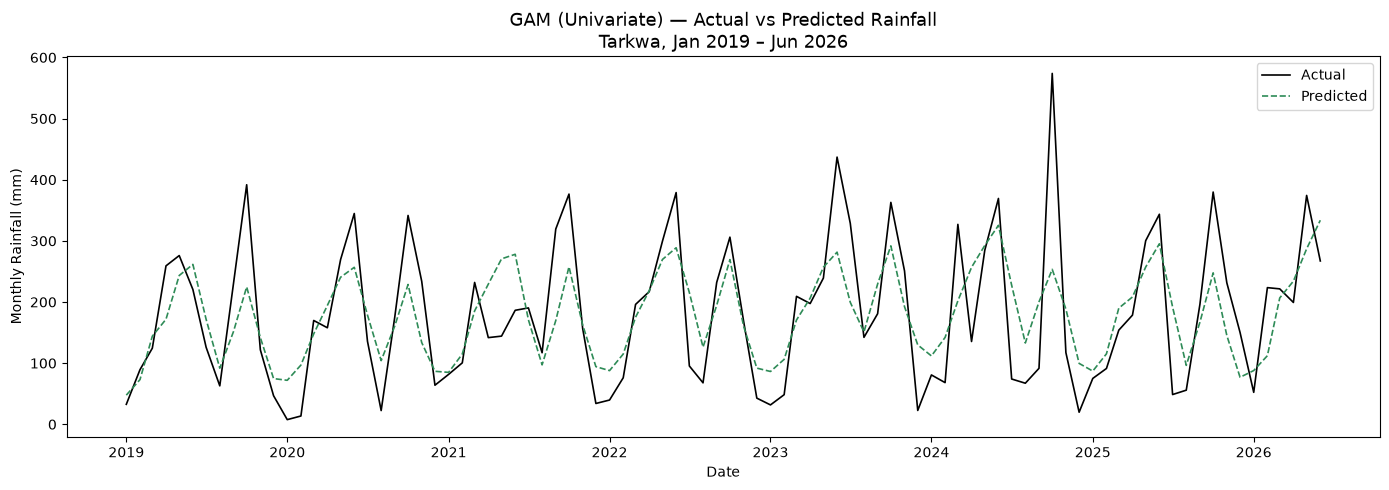

Plot saved.


In [6]:
plt.figure(figsize=(14, 5))
plt.plot(test_dates.values, y_test,       label='Actual',    color='black', linewidth=1.2)
plt.plot(test_dates.values, predictions,  label='Predicted', color='seagreen',
         linewidth=1.2, linestyle='--')
plt.title('GAM (Univariate) — Actual vs Predicted Rainfall\nTarkwa, Jan 2019 – Jun 2026',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('Monthly Rainfall (mm)')
plt.legend()
plt.tight_layout()
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/gam_uni_actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved.")

In [7]:
joblib.dump({
    'model_fit': gam_model,
    'predictors': ['t', 'month_num'],
    'model_type': 'GAM_univariate',
}, '../models/gam_uni_model.pkl')

results = {
    'model': 'GAM',
    'mode': 'univariate',
    'mae': round(mae, 2),
    'rmse': round(rmse, 2),
    'r2': round(r2, 4),
    'mape': round(mape, 2),
}
with open('../models/gam_uni_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Model saved to models/gam_uni_model.pkl")
print("Results saved to models/gam_uni_results.json")
print(f"\nSummary: GAM (univariate)")
print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")

Model saved to models/gam_uni_model.pkl
Results saved to models/gam_uni_results.json

Summary: GAM (univariate)
  MAE=61.88  RMSE=79.32  R²=0.5489  MAPE=72.41%
